<span style = "font-family: Verdana; font-size: 20px">

#### **Visualization**
</span>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.figure_factory as ff
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.ticker as mtick
from sklearn.manifold import TSNE
from PIL import Image
import openchord as ocd
from os import listdir

import unicodedata

In [6]:
data = pd.read_csv('data/modified/viz_pokemon.csv', keep_default_na=False, dtype = {'ID': str})

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  800 non-null    object 
 1   Name                800 non-null    object 
 2   Type 1              800 non-null    object 
 3   Type 2              800 non-null    object 
 4   HiddenAbility       800 non-null    object 
 5   Generation          800 non-null    int64  
 6   Hp                  800 non-null    float64
 7   Attack              800 non-null    float64
 8   Defense             800 non-null    float64
 9   SpecialAttack       800 non-null    float64
 10  SpecialDefense      800 non-null    float64
 11  Speed               800 non-null    float64
 12  TotalStats          800 non-null    float64
 13  Weight              800 non-null    float64
 14  Height              800 non-null    float64
 15  GenderProbM         800 non-null    float64
 16  Category

In [8]:
pd.options.display.max_columns = None
data

,ID,Name,Type 1,Type 2,HiddenAbility,Generation,Hp,Attack,Defense,SpecialAttack,SpecialDefense,Speed,TotalStats,Weight,Height,GenderProbM,Category,CatchRate,EggCycles,LevelingRate,BaseFriendship,IsLegendary,IsMythical,HasMega,EvoStage,TotalEvoStages,PreevoName,DamageFromNormal,DamageFromFighting,DamageFromFlying,DamageFromPoison,DamageFromGround,DamageFromRock,DamageFromBug,DamageFromGhost,DamageFromSteel,DamageFromFire,DamageFromWater,DamageFromGrass,DamageFromElectric,DamageFromPsychic,DamageFromIce,DamageFromDragon,DamageFromDark,DamageFromFairy,Ability 1,Ability 2,NoGender,EggGroup1,EggGroup2,IsMega,FightsWon,TotalFights,WinPercentage
0,1,Bulbasaur,Grass,Poison,Chlorophyll,1,45.0,49.0,49.0,65.0,65.0,45.0,318.0,6.9,0.7,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,0,1,3,No Preevolution,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.00,2.00,0.5,0.25,0.5,2.0,2.00,1.0,1.0,0.5,Overgrow,None,0,Monster,Grass,0,37,133,0.278195
1,2,Ivysaur,Grass,Poison,Chlorophyll,1,60.0,62.0,63.0,80.0,80.0,60.0,405.0,13.0,1.0,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,0,2,3,Bulbasaur,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.00,2.00,0.5,0.25,0.5,2.0,2.00,1.0,1.0,0.5,Overgrow,None,0,Monster,Grass,0,46,121,0.380165
2,3,Venusaur,Grass,Poison,Chlorophyll,1,80.0,82.0,83.0,100.0,100.0,80.0,525.0,100.0,2.0,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,1,3,3,Ivysaur,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.00,2.00,0.5,0.25,0.5,2.0,2.00,1.0,1.0,0.5,Overgrow,None,0,Monster,Grass,0,89,132,0.674242
3,4,Mega Venusaur,Grass,Poison,None,1,80.0,100.0,123.0,122.0,120.0,80.0,625.0,155.5,2.4,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,1,3,3,Venusaur,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.00,1.00,0.5,0.25,0.5,2.0,1.00,1.0,1.0,0.5,Thick Fat,None,0,Monster,Grass,1,70,125,0.560000
4,5,Charmander,Fire,Fire,Solar Power,1,39.0,52.0,43.0,60.0,50.0,65.0,309.0,8.5,0.6,0.875,Lizard Pokémon,45,20,Medium Slow,70,0,0,0,1,3,No Preevolution,1.0,1.0,1.0,1.0,2.0,2.0,0.5,1.0,0.50,0.50,2.0,0.50,1.0,1.0,0.50,1.0,1.0,0.5,Blaze,None,0,Monster,Dragon,0,55,112,0.491071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,Diancie,Rock,Fairy,None,6,50.0,100.0,150.0,100.0,150.0,50.0,600.0,8.8,0.7,0.500,Jewel Pokémon,3,25,Slow,70,0,1,1,1,1,No Preevolution,0.5,1.0,0.5,1.0,2.0,1.0,0.5,1.0,4.00,0.50,2.0,2.00,1.0,1.0,1.00,0.0,0.5,1.0,Clear Body,None,1,No Eggs Discovered,No Eggs Discovered,0,39,105,0.371429
796,797,Mega Diancie,Rock,Fairy,None,6,50.0,160.0,110.0,160.0,110.0,110.0,700.0,27.8,1.1,0.500,Jewel Pokémon,3,25,Slow,0,0,1,1,1,1,Diancie,0.5,1.0,0.5,1.0,2.0,1.0,0.5,1.0,4.00,0.50,2.0,2.00,1.0,1.0,1.00,0.0,0.5,1.0,Magic Bounce,None,1,No Eggs Discovered,No Eggs Discovered,1,116,131,0.885496
797,798,Hoopa Confined,Psychic,Ghost,None,6,80.0,110.0,60.0,150.0,130.0,70.0,600.0,9.0,0.5,0.500,Mischief Pokémon,3,120,Slow,100,0,1,0,1,1,No Preevolution,0.0,0.0,1.0,0.5,1.0,1.0,1.0,4.0,1.00,1.00,1.0,1.00,1.0,0.5,1.00,1.0,4.0,1.0,Magician,None,1,No Eggs Discovered,No Eggs Discovered,0,60,119,0.504202
798,799,Hoopa Unbound,Psychic,Dark,None,6,80.0,160.0,60.0,170.0,130.0,80.0,680.0,9.0,0.5,0.500,Mischief Pokémon,3,120,Slow,100,0,1,0,1,1,No Preevolution,1.0,1.0,1.0,1.0,1.0,1.0,4.0,1.0,1.00,1.00,1.0,1.00,1.0,0.0,1.00,1.0,1.0,2.0,Magician,None,1,No Eggs Discovered,No Eggs Discovered,0,89,144,0.618056


In [9]:
data.columns = [c.strip() for c in data.columns]
numeric_cols  = data.select_dtypes(include=[np.number]).columns.tolist()
object_cols   = data.select_dtypes(include=["object"]).columns.tolist()
print(f"Shape: {data.shape}")
print("-" * 30) 
print(f"Numeric ({len(numeric_cols)} cols):   {numeric_cols}")
print(f"Object ({len(object_cols)} cols):    {object_cols}")

Shape: (800, 54)
------------------------------
Numeric (42 cols):   ['Generation', 'Hp', 'Attack', 'Defense', 'SpecialAttack', 'SpecialDefense', 'Speed', 'TotalStats', 'Weight', 'Height', 'GenderProbM', 'CatchRate', 'EggCycles', 'BaseFriendship', 'IsLegendary', 'IsMythical', 'HasMega', 'EvoStage', 'TotalEvoStages', 'DamageFromNormal', 'DamageFromFighting', 'DamageFromFlying', 'DamageFromPoison', 'DamageFromGround', 'DamageFromRock', 'DamageFromBug', 'DamageFromGhost', 'DamageFromSteel', 'DamageFromFire', 'DamageFromWater', 'DamageFromGrass', 'DamageFromElectric', 'DamageFromPsychic', 'DamageFromIce', 'DamageFromDragon', 'DamageFromDark', 'DamageFromFairy', 'NoGender', 'IsMega', 'FightsWon', 'TotalFights', 'WinPercentage']
Object (12 cols):    ['ID', 'Name', 'Type 1', 'Type 2', 'HiddenAbility', 'Category', 'LevelingRate', 'PreevoName', 'Ability 1', 'Ability 2', 'EggGroup1', 'EggGroup2']


<span style = "font-family: Verdana; font-size: 20px">

##### **Color defining**
</span>

In [10]:
STATS = ['Hp','Attack','Defense','SpecialAttack','SpecialDefense','Speed']


COLOR_TYPES = {'Normal': '#9fa19f',
               'Fighting': '#ff8101',
               'Flying': '#81b9ef',
               'Poison': '#9142cb',
               'Ground': '#925122',
               'Rock': '#a9af82',
               'Bug': '#91a119',
               'Ghost': '#714171',
               'Steel': '#61a1b9',
               'Fire': '#e72829',
               'Water': '#2881f0',
               'Grass': '#3fa22a',
               'Electric': '#fac000',
               'Psychic': '#f0417a',
               'Ice': '#3fcdf3',
               'Dragon': '#5060e2',
               'Dark': '#624d4f',
               'Fairy': '#ef71ef'
               }

COLOR_STATS = {'Hp': '#11ad1e',
               'Attack': '#ff0000',
               'Defense': '#ff9500',
               'SpecialAttack': '#00ddff',
               'SpecialDefense': '#3a12c9',
               'Speed': '#ea00ff',
               'TotalStats': '#8c00ff'
               }

COLOR_EGGGROUPS = {'Monster': '#98734d',
               'Human-Like': '#47b7ae',
               'Water 1': '#6bd1f9',
               'Water 3': '#2271b4',
               'Bug': '#abc229',
               'Mineral': '#979067',
               'Flying': '#90aff1',
               'Amorphous': '#a082cc',
               'Field': '#e5ba65',
               'Water 2': '#4c94ee',
               'Fairy': '#ff9eb9',
               'Ditto': '#b6aad5',
               'Grass': '#83d35a',
               'Dragon': '#5e58bf',
               'No Eggs Discovered': '#efd004'
               }

NUM_GEN = data['Generation'].max()

<span style = "font-family: Verdana; font-size: 20px">

##### **Basic Informations**

<span style = "font-family: Verdana; font-size: 20px">

**Numerical features distribution**

In [11]:
def num_histogram(data, feature, lineartick = False):
    df = data.groupby(feature).value_counts().reset_index(name='Count')
    
    fig = go.Figure(px.histogram(df,
                                 x = feature,
                                 y = 'Count',
                                 ))
    fig.update_layout(bargap = 0.1,
                      yaxis_title = dict(text='Count'),
                      title = dict(
                          text = f'<br>Distribution of {feature}',
                          font = dict(size=16)
                          ),
    )
    if lineartick:
        fig.update_xaxes(tickmode='linear')
    else:
        pass
    fig.show()

In [12]:
for col in numeric_cols:
    if col in ['IsLegendary', 'IsMythical', 
               'HasMega', 'IsMega', 'NoGender']:
        num_histogram(data, col, lineartick = True)
    elif col == 'Generation':
        datagen = data.copy()
        datagen[col] = data[col].replace({1: 'I', 2: 'II', 3: 'III', 
                                     4: 'IV', 5: 'V', 6: 'VI'})
        num_histogram(datagen, col, lineartick = True)
    else:
        num_histogram(data, col)

<span style = "font-family: Verdana; font-size: 20px">

**Number of Pokémon by type/generation**

In [13]:
d1 = data.groupby('Generation')['Type 1'].value_counts().reset_index(name ='Count')
d2 = data.groupby('Generation')['Type 2'].value_counts().reset_index(name ='Count')
d1['Count'] = d1['Count'] * 0.5
d2['Count'] = d2['Count'] * 0.5

n_type = d1.copy()
n_type = n_type.rename({'Type 1': 'Type'}, axis=1)

for gen in range(1, NUM_GEN+1):
    for poktype in COLOR_TYPES.keys():
        if n_type.loc[(n_type["Type"] == poktype) & (n_type["Generation"] == gen), 'Count'].empty:
            n_type.loc[len(n_type.index)] = [gen, poktype, 0.0]
        if not d2.loc[(d2["Type 2"] == poktype) & (d2["Generation"] == gen), 'Count'].empty:
            n_type.loc[(n_type["Type"] == poktype) & (n_type["Generation"] == gen), 'Count'] += d2.loc[(d2["Type 2"] == poktype) & (d2["Generation"] == gen), 'Count'].values[0]
n_type['Generation'] = n_type['Generation'].replace({1: 'I', 2: 'II', 3: 'III', 4: 'IV', 5: 'V', 6: 'VI'})
print(d1, d2)
print(n_type)

    Generation    Type 1  Count
0            1     Water   15.5
1            1    Normal   12.0
2            1       Bug    7.0
3            1      Fire    7.0
4            1    Poison    7.0
..         ...       ...    ...
93           6  Electric    1.5
94           6  Fighting    1.5
95           6    Flying    1.0
96           6       Ice    1.0
97           6    Poison    1.0

[98 rows x 3 columns]      Generation    Type 2  Count
0             1    Poison   16.0
1             1    Flying   11.5
2             1     Water   11.5
3             1   Psychic    8.0
4             1    Normal    6.5
..          ...       ...    ...
98            6      Dark    1.5
99            6       Bug    1.0
100           6  Fighting    1.0
101           6      Fire    1.0
102           6    Ground    1.0

[103 rows x 3 columns]
    Generation    Type  Count
0            I   Water   27.0
1            I  Normal   18.5
2            I     Bug    8.5
3            I    Fire   12.0
4            I  Poison 

In [14]:
fig = go.Figure(px.histogram(n_type, 
                                 y = "Type",
                                 x = "Count", 
                                 color = "Type", 
                                 title = "Wide-Form Input", 
                                 color_discrete_map=COLOR_TYPES))
fig.update_layout(bargap = 0.1,
    yaxis_title = dict(text='Type'),
    xaxis_title = dict(text='Number of Pokémon by type'),
    title=dict(
                text = f"<br>Number of Pokémon by type",
                font = dict(
                    size = 16
                )
            ),
    title_x=0.5,
)
fig.show()

fig = fig=go.Figure(px.histogram(n_type, 
                                 y="Generation",
                                 x="Count", 
                                 color="Generation", 
                                 title="Wide-Form Input", 
                                 color_discrete_map=COLOR_TYPES))
fig.update_layout(bargap=0.2,
    yaxis_title=dict(text='Generation'),
    xaxis_title=dict(text='Number of Pokémon by Generation'),
    title=dict(
                text=f"<br>Number of Pokémon by type",
                font=dict(
                    size=16
                )
            ),
    title_x=0.5,
)
fig.show()

<span style = "font-family: Verdana; font-size: 20px">

**Basic stats by type**

In [15]:
def stat_boxplot(data, stat):
    # Build a dataframe with one row per Pokémon-stat value and its corresponding type (Type 1 or Type 2)
    types = []
    values = []
    for t in COLOR_TYPES.keys():
        mask_t = (data['Type 1'] == t) | (data['Type 2'] == t)
        if mask_t.any():
            types.extend([t] * int(mask_t.sum()))
            values.extend(data.loc[mask_t, stat].tolist())
    df_plot = pd.DataFrame({'Type': types, stat: values})

    fig = go.Figure()
    fig.add_trace(go.Box(
        x=df_plot['Type'],
        y=df_plot[stat],
        boxpoints='outliers',
        jitter=0,
        pointpos=0,
        marker_color=COLOR_STATS[stat],
        line_color=COLOR_STATS[stat],
        name=stat
    ))
    fig.update_layout(
        title=dict(
            text=f"<br>Boxplot of {stat}",
            font=dict(size=16)
        ),
        xaxis_title=dict(text='Type'),
        yaxis_title=dict(text=stat),
        showlegend=False,
        xaxis=dict(tickangle=-90)
    )
    fig.update_xaxes(categoryorder='array', categoryarray=list(COLOR_TYPES.keys()))
    fig.show()

In [16]:
stat_cols = ['Hp', 'Attack', 'Defense', 'SpecialAttack', 'SpecialDefense', 'Speed', 'TotalStats']
for stat in stat_cols:
    stat_boxplot(data, stat)

<span style = "font-family: Verdana; font-size: 20px">

**Types combination**

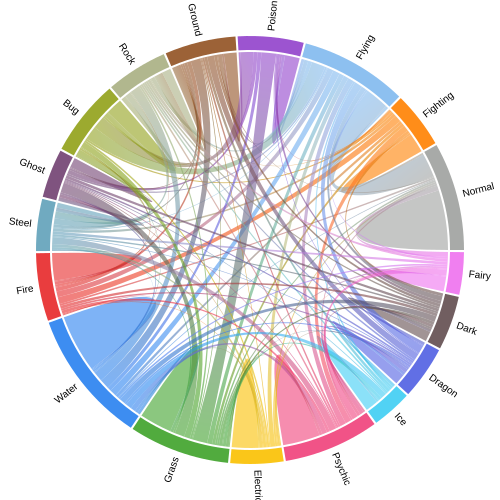

In [19]:
matrix = data.groupby(['Type 1','Type 2']).size().unstack(fill_value=0)
matrix = matrix[COLOR_TYPES.keys()].loc[COLOR_TYPES.keys()]
adjacency_matrix = matrix.copy()

for i in range(len(matrix)):
    for j in range(len(matrix)):
        if not j == i:
            adjacency_matrix.loc[matrix.keys()[i], matrix.keys()[j]] += matrix[matrix.keys()[i]][matrix.keys()[j]]


labels = list(COLOR_TYPES.keys())

fig = ocd.Chord(adjacency_matrix, labels)
fig.colormap = list(COLOR_TYPES.values())

fig.show()

<span style = "font-family: Verdana; font-size: 20px">

##### **Ideas(?)**

- Difference between offensive and defensive stats.
- Ratio between physical/special stats.
- Graph study where pokemons are related when they have similar movements, and the weight of the arc depends on the proportion of shared movements.
- Evolution stage graphics.
</span>

<span style = "font-family: Verdana; font-size: 20px">

##### **Pokémon Type**

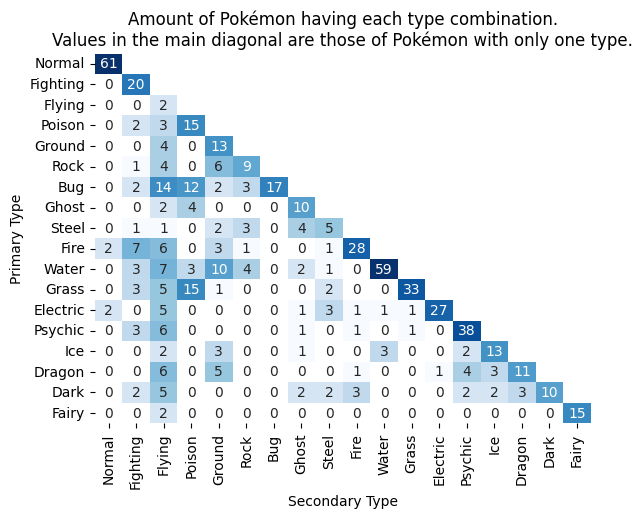

In [18]:
matrix = data.groupby(['Type 1','Type 2']).size().unstack(fill_value=0)
matrix = matrix[COLOR_TYPES.keys()].loc[COLOR_TYPES.keys()]

mask = np.triu(np.ones(matrix.shape, dtype=bool), k=1)

cmap = plt.colormaps.get_cmap('Blues').copy()
cmap.set_bad('white')
cmap.set_under('white')

plt.title("Amount of Pokémon having each type combination.\nValues in the main diagonal are those of Pokémon with only one type.")
sns.heatmap(matrix, annot=True, cmap=cmap, norm=LogNorm(), cbar=False, mask=mask)
plt.ylabel("Primary Type")
plt.xlabel("Secondary Type")
plt.show()